# Episodes: choosing θ and the gap tolerance

**Pipeline position.** `gatherings_v1.parquet` (one row per group per 5-minute slot) → **episodes** (this notebook) → feature table → preprocessing → clustering.

**Why.** A row is a snapshot, not a gathering: the same group seen for two hours is 24 rows. Duration, number of slots and recurrence only exist once consecutive rows are linked into episodes, and duplicated near-identical rows would inflate cluster-validity scores.

**Definitions**

- Jaccard similarity of two member sets: $J(A,B)=\dfrac{|A\cap B|}{|A\cup B|}$ (asymmetric binary attributes: absent-from-both is not a match).
- **θ**: two rows are the same group if $J \ge \theta$.
- **g (gap tolerance)**: a group may be unseen for up to $g$ consecutive slots and still continue. A link from slot $t$ to slot $t+1+k$ skips $k\le g$ slots.
- **Linking rule.** Collect candidate links with $J\ge\theta$ and at most $g$ skipped slots. Accept them shortest gap first, then highest $J$. Each row gets at most one successor and one predecessor. A chain of accepted links is one **episode**.

**Why shortest gap first.** If the next slot already offers a valid link, skipping a slot would orphan the in-between row.

**What the grid measures** (no labelled meetings exist, so the evidence is internal):

| Measure | What it tells you |
|---|---|
| episodes | how many gatherings the data contain at this setting |
| single_slot_% | share of episodes lasting one slot; high means the linking is strict |
| median / p95 / max slots | duration distribution; a few 24-hour episodes would be a warning |
| bridged_gap_slots | how many skipped slots the gap tolerance used |
| end_to_end_j (long episodes) | $J$ between first and last row of episodes of 5+ slots; low means the group drifted (chaining) |

**What the output does not mean.** An episode is a group that looked continuously co-present in the Bluetooth data. It says nothing about whether the students interacted.

In [14]:
from pathlib import Path
import sys
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().parent                   # notebooks/ is one level below the project root
PROCESSED = PROJECT_ROOT / "data" / "processed"

sys.path.append(str(PROJECT_ROOT))                 # so "from src..." works inside notebooks/
from src.config import load_config
cfg = load_config(PROJECT_ROOT / "config" / "config.yaml")
SLOT_SEC = cfg["time_parameters"]["slot_duration_sec"]   # seconds per slot (300)

THETAS = [0.4, 0.5, 0.6, 0.7, 0.8, 0.9]            # similarity thresholds to try
GAPS = [0, 1, 2, 3]                                # numbers of skipped slots to tolerate

## 1. Linking functions

`candidate_edges` goes through every row and, for each of the next `gap_max + 1` slots, compares its member set with the rows in that slot (pairs with no shared member are skipped). It keeps the pairs with $J\ge\theta_{\min}$ together with the number of skipped slots. `accept_links` applies one $(\theta, g)$ setting to those candidates and takes them best first, so that every row gets at most one successor and one predecessor. `link_rows` follows the accepted links and returns the episodes.

In [15]:
# the three linking functions now live in the project module
from src.features.episodes import candidate_edges, accept_links, link_rows

## 2. Sanity check on the hand example

The first 17 rows of `gatherings_v1` (slots 0 to 4) were linked by hand. The code must give the same episode counts: **8** at (θ=0.6, g=0), **6** at (0.6, 1), **10** at (0.8, 0) and **7** at (0.8, 1).

In [16]:
toy_slots = [0,0,0, 1,1,1,1, 2,2,2, 3,3,3, 4,4,4,4]
toy_sets = [
    {12,244,454}, {176,221,263,472}, {215,311,524},
    {57,101,586}, {12,244,454}, {221,263,472}, {282,455,621},
    {12,244,454}, {176,221,263,472}, {282,455,621},
    {57,101,586}, {12,244,454}, {176,221,263,472},
    {64,90,91}, {57,101,586}, {176,221,263,452,472}, {282,455,621},
]
toy_edges = candidate_edges(toy_slots, toy_sets, 0.4, 3)
expected = {(0.6, 0): 8, (0.6, 1): 6, (0.8, 0): 10, (0.8, 1): 7}
for (theta, g), n_expected in expected.items():
    n = len(link_rows(toy_edges, len(toy_sets), theta, g))
    print(f"theta={theta} g={g}: {n} episodes (hand count {n_expected})")
    assert n == n_expected

theta=0.6 g=0: 8 episodes (hand count 8)
theta=0.6 g=1: 6 episodes (hand count 6)
theta=0.8 g=0: 10 episodes (hand count 10)
theta=0.8 g=1: 7 episodes (hand count 7)


## 3. Load the gatherings and compute candidate links once

In [17]:
gath = pd.read_parquet(PROCESSED / "gatherings_v1.parquet").sort_values(["slot_id", "gathering_id"]).reset_index(drop=True)
slot_of = gath["slot_id"].to_numpy()                                         # slot of every row
members = [frozenset(int(u) for u in a) for a in gath["participant_set"]]    # member set of every row
print(f"{len(gath):,} slot-level gatherings, slots {slot_of.min()}..{slot_of.max()}")

t0 = time.time()
edges = candidate_edges(slot_of, members, min(THETAS), max(GAPS))            # computed once, loosest settings
print(f"{len(edges):,} candidate links in {time.time() - t0:.0f}s")

98,194 slot-level gatherings, slots 0..8063
300,351 candidate links in 1s


## 4. Grid over θ and g

For each setting the table reports the measures described at the top. `n_span` counts the slots an episode covers, gaps included. Long episodes are those with `n_span >= 5` (25 minutes or more).

In [18]:
def episode_table(episodes):
    # one row per episode with its basic measures
    rows = []
    for chain in episodes:
        first_row = chain[0]
        last_row = chain[-1]
        first_slot = slot_of[first_row]
        last_slot = slot_of[last_row]
        n_span = last_slot - first_slot + 1                 # slots covered, gaps included

        everyone = set()                                    # all members that appear anywhere in the chain
        for k in chain:
            everyone = everyone | members[k]

        a = members[first_row]
        b = members[last_row]
        end_to_end_j = len(a & b) / len(a | b)              # how much the group drifted from start to end

        rows.append({"first_slot": first_slot, "last_slot": last_slot,
                     "n_rows": len(chain), "n_span": n_span,
                     "n_gap_slots": n_span - len(chain),    # slots covered but without a row
                     "union_size": len(everyone), "end_to_end_j": end_to_end_j})
    return pd.DataFrame(rows)


records = []
for g in GAPS:
    for theta in THETAS:
        episodes = link_rows(edges, len(gath), theta, g)
        ep = episode_table(episodes)
        long_ep = ep[ep.n_span >= 5]                        # episodes of 25 minutes or more
        records.append({
            "theta": theta, "gap": g, "episodes": len(ep),
            "single_slot_%": 100 * (ep.n_span == 1).mean(),
            "median_slots": ep.n_span.median(),
            "p95_slots": ep.n_span.quantile(.95),
            "max_slots": ep.n_span.max(),
            "bridged_gap_slots": int(ep.n_gap_slots.sum()),
            "end_to_end_j_median(long)": long_ep.end_to_end_j.median(),
            "end_to_end_j<0.5_%(long)": 100 * (long_ep.end_to_end_j < 0.5).mean(),
        })
grid = pd.DataFrame(records)
grid.round(2)

,theta,gap,episodes,single_slot_%,median_slots,p95_slots,max_slots,bridged_gap_slots,end_to_end_j_median(long),end_to_end_j<0.5_%(long)
0,0.4,0,18758,48.35,2.0,22.0,286,0,0.75,26.15
1,0.5,0,20523,50.08,1.0,20.0,184,0,0.75,21.59
2,0.6,0,24270,54.19,1.0,16.0,184,0,0.80,12.96
3,0.7,0,29184,57.91,1.0,12.0,184,0,0.89,4.71
4,0.8,0,36883,63.47,1.0,9.0,184,0,1.00,0.75
5,0.9,0,44434,68.74,1.0,7.0,184,0,1.00,0.00
6,0.4,1,13034,43.56,2.0,36.0,288,5724,0.75,31.37
7,0.5,1,14740,46.21,2.0,30.0,290,5783,0.75,27.15
8,0.6,1,18269,51.19,1.0,24.0,184,6001,0.75,17.32
9,0.7,1,22530,54.87,1.0,19.0,184,6654,0.83,6.33


### Reading the grid table

One row per setting (θ, g). One slot = 5 minutes. `n_span` = slots an episode covers, gaps included.

- `theta`: minimum Jaccard similarity for two rows to count as the same group. Higher = stricter.
- `gap`: max number of consecutive slots a group may be unseen and still continue. 0 = consecutive slots only.
- `episodes`: number of chains found (rows − accepted links). Fewer = more merging.
- `single_slot_%`: share of episodes seen in one slot only (`n_span == 1`). High = strict linking or many brief groups.
- `median_slots`: median `n_span`. Often 1, so it moves little.
- `p95_slots`: 95th percentile of `n_span`. Shows how long the longer episodes get.
- `max_slots`: longest episode. A very long one (e.g. 184 slots ≈ 15 h) needs a check by hour: real overnight co-location or drift.
- `bridged_gap_slots`: total slots inside episodes that have no row. Always 0 when gap = 0.
- `end_to_end_j_median(long)`: median J between first and last row of long episodes (`n_span >= 5`). Near 1 = same group at both ends.
- `end_to_end_j<0.5_%(long)`: share of long episodes whose first and last rows overlap by less than half. Chaining/drift indicator.

**Reading it**
- Lower θ and higher gap give fewer, longer, more mixed episodes. Higher θ and lower gap give the opposite.
- Look for where `episodes` stops dropping fast while the drift column is still small.
- Internal evidence only: no labelled meetings exist.

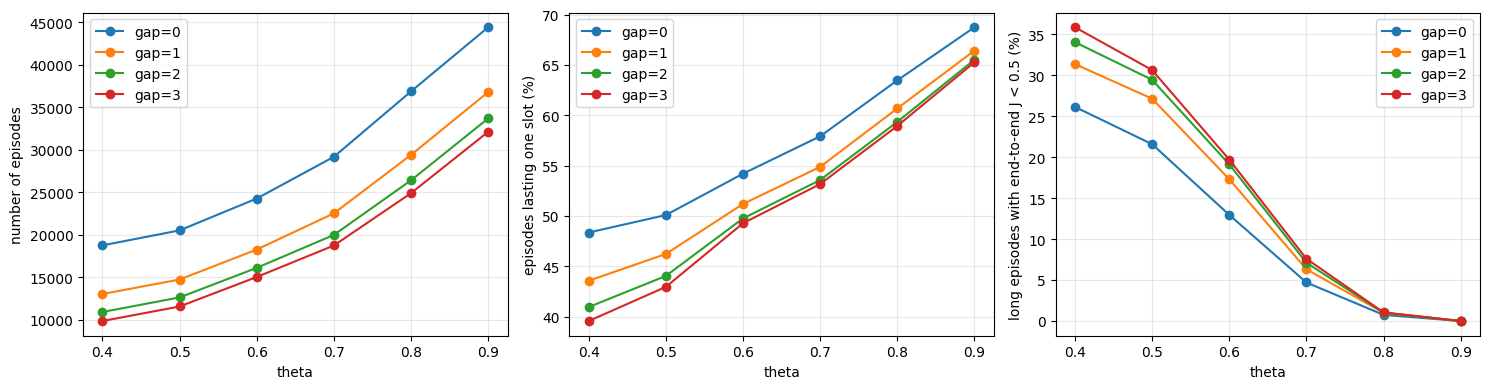

In [19]:
panels = {"episodes": "number of episodes",
          "single_slot_%": "episodes lasting one slot (%)",
          "end_to_end_j<0.5_%(long)": "long episodes with end-to-end J < 0.5 (%)"}

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (column, label) in zip(axes, panels.items()):       # one panel per measure
    for g in GAPS:                                          # one line per gap
        sub = grid[grid.gap == g]
        ax.plot(sub.theta, sub[column], marker="o", label=f"gap={g}")
    ax.set(xlabel="theta", ylabel=label)
    ax.legend()
    ax.grid(alpha=.3)
plt.tight_layout()
plt.show()

### Reading the plots

- **Number of episodes:** rises with θ. A larger gap lowers it, mostly from gap 0 → 1; gaps 2 and 3 add little. No sharp knee.
  - *Meaning:* low θ merges more rows into one episode. High θ splits a group whenever members change. A gap of 1 repairs most missed observations, while gaps 2 and 3 repair few more.
- **One-slot episodes (%):** rises with θ. A larger gap lowers it only a few points, and the lines converge at high θ.
  - *Meaning:* at high θ many groups are never linked and stay as single snapshots. Gap tolerance can't rescue them, since these groups are not similar enough to their neighbours.
- **Long episodes with end-to-end J < 0.5 (%):** high at low θ (worse with larger gap), drops fast between θ=0.5 and 0.7, about 0 from θ=0.8.
  - *Meaning:* at low θ, chains grow by small steps until the end group is a different group from the start (chaining). Above θ≈0.7, links are strict enough that start and end stay the same group.
- **Trade-off:** low θ drifts, high θ fragments. Pick where drift is already low but fragmentation hasn't exploded.

## 5. Were the bridged gaps silent phones?

A gap is only a missed observation if the members' phones logged nothing, or were present but just under the threshold. For every bridged link we look at the members seen on both sides of the gap and check whether each one logged **any** scan row in each skipped slot (from `bt_symmetric_prepared.parquet`). The baseline is how often a participant's phone is silent in a random slot.

Caution on the comparison: members of a group are active at both ends of the gap by construction, so they are expected to be less silent than the average participant.

In [20]:
bt = pd.read_parquet(PROCESSED / "bt_symmetric_prepared.parquet", columns=["timestamp", "user_a"])
n_users = int(bt.user_a.max()) + 1
n_slots = int(slot_of.max()) + 1

# scanned[u, s] is True if phone u logged at least one row in slot s
scanned = np.zeros((n_users, n_slots), dtype=bool)
scan_slot = bt.timestamp.to_numpy() // SLOT_SEC             # slot of every logged row
scanned[bt.user_a.to_numpy(), scan_slot] = True

active_users = np.unique(bt.user_a)
baseline_silent = 100 * (1 - scanned[active_users].mean())  # share of (user, slot) cells with no scan
print(f"baseline: a participant's phone is silent in {baseline_silent:.1f}% of all slots")


def gap_silence(theta, g):
    # for every bridged link, check if the members seen on both sides logged anything in the skipped slots
    silent = 0
    total = 0
    successor = accept_links(edges, theta, g)
    for i, j in successor.items():
        skipped_slots = range(slot_of[i] + 1, slot_of[j])   # empty when the link skips no slot
        both_sides = members[i] & members[j]                # members present before and after the gap
        for u in both_sides:
            for s in skipped_slots:
                total += 1
                if not scanned[u, s]:
                    silent += 1
    return silent, total


for theta in (0.5, 0.6, 0.7):
    for g in (1, 2, 3):
        silent, total = gap_silence(theta, g)
        print(f"theta={theta} g={g}: {100 * silent / max(total, 1):.1f}% of member-slots inside bridged gaps were silent ({total:,} checked)")

baseline: a participant's phone is silent in 31.7% of all slots
theta=0.5 g=1: 20.1% of member-slots inside bridged gaps were silent (25,315 checked)
theta=0.5 g=2: 20.4% of member-slots inside bridged gaps were silent (42,155 checked)
theta=0.5 g=3: 20.2% of member-slots inside bridged gaps were silent (55,286 checked)
theta=0.6 g=1: 17.8% of member-slots inside bridged gaps were silent (30,729 checked)
theta=0.6 g=2: 17.9% of member-slots inside bridged gaps were silent (51,773 checked)
theta=0.6 g=3: 17.6% of member-slots inside bridged gaps were silent (69,110 checked)
theta=0.7 g=1: 16.9% of member-slots inside bridged gaps were silent (36,272 checked)
theta=0.7 g=2: 17.2% of member-slots inside bridged gaps were silent (62,624 checked)
theta=0.7 g=3: 16.9% of member-slots inside bridged gaps were silent (83,999 checked)


## 6. A fairer baseline for the silent-phone check

Section 5 compared silence inside bridged gaps with a random slot (31.7%). That baseline is too high, because group members were active on both sides of a gap by construction. This block computes how often a phone is silent in a slot, given that it logged something in the slot before and the slot after. This is the fair baseline for a gap of one slot.

Compare it with the silent share inside bridged gaps from section 5. A much higher share inside gaps means silent phones contribute to the gaps. A similar share means they occur by chance.

Caution: this baseline applies to one-slot gaps only.

In [21]:
sc = scanned[np.unique(bt.user_a)]                  # active phones only
before, middle, after = sc[:, :-2], sc[:, 1:-1], sc[:, 2:]
active_both_sides = before & after                  # phone logged in slot s-1 and s+1
silent_in_middle = 100 * (~middle[active_both_sides]).mean()
print(silent_in_middle)

2.952258295177076


## 7. Are the longest episodes overnight co-location or drift?

The longest episodes (up to 184 slots, about 15 hours) are suspicious: nobody stays in one meeting that long. This block links the rows at the chosen setting (θ = 0.7, g = 1) and, for episodes of 3 hours or more, computes the start and end hour, the share of the episode that falls between 00:00 and 07:00, and the end-to-end $J$.

High end-to-end $J$ with night hours means people sharing the same place overnight. Low $J$ means a chain that drifted from one group into another.

Caution: the hours assume timestamp 0 = midnight, which the dataset authors withhold.

In [22]:
episodes = link_rows(edges, len(gath), 0.7, 1)                 # chosen setting
ep = episode_table(episodes)
ep["start_hour"] = (ep.first_slot * SLOT_SEC // 3600) % 24     # assumes timestamp 0 = midnight
ep["end_hour"] = (ep.last_slot * SLOT_SEC // 3600) % 24

print(ep.sort_values("n_span", ascending=False).head(10)[["first_slot", "n_span", "union_size", "end_to_end_j", "start_hour", "end_hour"]])

long_ep = ep[ep.n_span >= 36]                                  # 3 hours or more
print(long_ep.start_hour.value_counts().sort_index())

def night_share(row):                                          # share of the episode's slots between 00:00 and 07:00
    slots = np.arange(row.first_slot, row.last_slot + 1)
    hours = (slots * SLOT_SEC // 3600) % 24
    return (hours < 7).mean()

long_ep = long_ep.assign(night=long_ep.apply(night_share, axis=1))
print((long_ep.night >= 0.8).mean(), long_ep.end_to_end_j.median())

       first_slot  n_span  union_size  end_to_end_j  start_hour  end_hour
8218         3117     184           3           1.0          19        11
10748        3975     181           3           1.0          19        10
19345        6890     165           5           0.5          22        11
7124         2812     160           5           0.6          18         7
17339        6311     145           5           0.5          21         9
3509         1426     144           5           0.5          22        10
13280        4847     143           4           1.0          19         7
15349        5464     141           6           0.2          23        11
17325        6303     135           5           1.0          21         8
5000         2273     134           5           0.5          21         8
start_hour
0     31
1     20
2     18
3     19
4     13
5      8
6      3
7      8
8     28
9     15
10     5
11     3
12    28
13    19
14     6
15     4
16     9
17    23
18    20
19  

### Findings: long episodes

- **When:** the ten longest episodes (up to 184 slots, about 15 hours) all start between 18:00 and 23:00 and end between 07:00 and 11:00. So they are overnight episodes.
- **Who:** their unions are small, 3 to 6 people in total. The longest is the same three people from start to end (end-to-end J = 1.0).
- **Drift:** the episodes with end-to-end J of 0.2–0.6 involve 5–6 people, so they are small groups where one or two members come and go. They are not different meetings joined together by chaining.
- **Share at night:** of the 392 episodes of 3 hours or more, 26% have at least 80% of their span between 00:00 and 07:00. The median end-to-end J is 0.77.

**Conclusion:** the long episodes look like overnight co-location of small, stable groups. We keep them and add `start_hour` and `night_share` as flag columns. Duration will need a robust scale in the feature table.

**Caution:** hours assume timestamp 0 = midnight. Bluetooth proximity does not show where the groups are, so "overnight co-location" could be a shared residence or time spent on campus. Some trios recur on many nights (one trio on 9 nights), which fits a shared place better than occasional all-nighters, but many cores occur only once.

## 8. Should one-slot episodes be kept?

Most episodes (55%) consist of a single row. This block lists them and compares them with the other episodes: the share of all rows they cover, their group size and their median RSSI.

If they were small, weak-signal noise we would drop them. Duration features carry no information for them, so we keep `n_slots` as a column and run the clustering with and without them as a sensitivity check.

In [23]:
single = [chain[0] for chain in episodes if len(chain) == 1]   # rows that stayed alone
print(len(single) / len(gath))
sizes = gath.participant_set.apply(len)
print(sizes.iloc[single].describe(), gath.median_rssi.iloc[single].median())

0.1258936391225533
count    12362.000000
mean         7.559052
std         11.749259
min          3.000000
25%          3.000000
50%          4.000000
75%          6.000000
max        173.000000
Name: participant_set, dtype: float64 -82.5


## 9. Does the choice hold at RSSI −80 and −85?

The grid in section 4 used gatherings built at −90 dBm. This block reruns the same grid on gatherings built at −80 and −85 dBm and compares the three measures that decided the choice: number of episodes, single-slot share and drift.

The choice holds if drift still drops steeply up to θ = 0.7 and flattens afterwards.

Caution: run it only after the gatherings at those thresholds have been built.

## 10. Decision record

**Chosen: θ = 0.7, g = 1** (a group may be unseen for one slot, i.e. 5 minutes)

**Why θ = 0.7**
- Drift drops steeply up to 0.7, then flattens. Long episodes whose end no longer matches the start: 17% at θ=0.6, 6% at 0.7, 1% at 0.8.
- Above 0.7 the episodes fragment: 22,530 at θ=0.7 vs 29,411 at 0.8 (+31%), and single-slot episodes rise from 55% to 61%.
- In people terms: a group of 4 can lose or gain one member and stay the same episode. A one-member swap breaks the link.

**Why g = 1**
- The biggest gain comes from gap 0 → 1 (−23% episodes). Gap 2 adds −11%, gap 3 adds −6%.
- Larger gaps add drift (6.3% → 7.1% → 7.6%) and longer maximum episodes (184 → 234 slots).
- Bridged one-slot gaps are partly missed scans: 16.9% of the member-slots inside them logged nothing, against 3.0% for a phone that scanned in the slot before and after (about 6× chance). Still, 83% of member-slots inside gaps logged scans, so a gap is not simply a switched-off phone.

**Rejected**
- θ ≤ 0.6: too much drift. θ ≥ 0.8: too fragmented.
- g = 0: splits a group after one missed scan. g ≥ 2: little gain, more drift.

**Sensitivity:** repeat the downstream clustering at θ = 0.6 and θ = 0.8 (g = 1).

**Answered by the checks**
- Very long episodes (up to 184 slots, about 15 h): overnight co-location of small, stable groups, not chain drift (section 7). Kept and flagged with `start_hour` and `night_share`.
- Silent phones in gaps: about 6× chance, but most members in a gap still logged scans (section 6).
- One-slot episodes (55% of episodes, 12.6% of rows): kept, with `n_slots` as a column (section 8).

**Still open**
- Does the choice hold at RSSI −80 and −85? The grid used −90 (section 9).

**Cautions**
- Hours assume timestamp 0 = midnight, which the dataset authors withhold.
- Overnight co-location could be a shared residence or time spent on campus; Bluetooth cannot tell which.
- The 3.0% baseline is exact only for one-slot gaps.

## 11. Schema of `episodes_v1`

One row per episode, built from `gatherings_v1` at the chosen setting (θ = 0.7, g = 1).

| Column | Meaning |
|---|---|
| `episode_id` | running id |
| `first_slot`, `last_slot` | first and last slot that has a row |
| `start_time`, `end_time` | `start_time` of the first row, `end_time` of the last row |
| `n_slots` | slots covered from first to last, gaps included (duration in 5-minute slots) |
| `n_gap_slots` | covered slots without a row (rows = `n_slots` − `n_gap_slots`) |
| `gathering_ids` | the `gathering_id` of every row in the chain |
| `participant_set` | everyone who appears in any row |
| `median_size` | median participants per row |
| `median_rssi` | median of the rows' `median_rssi` |
| `start_hour` | hour of the first slot (0–23); assumes timestamp 0 = midnight |
| `night_share` | share of covered slots between 00:00 and 07:00 |

Night-time rule: flag columns only, no filter in v1.